# Zachary's Karate Club Network

This notebook loads the built-in Zachary's Karate Club graph from NetworkX, visualizes it, and reports basic graph statistics.


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

%matplotlib inline


In [2]:
G = nx.karate_club_graph()
print(f'Number of nodes: {G.number_of_nodes()}')
print(f'Number of edges: {G.number_of_edges()}')

degrees = sorted(G.degree(), key=lambda x: x[1], reverse=True)
top_five = degrees[:5]
print('Five highest-degree nodes:')
for node, degree in top_five:
    print(f'  Node {node}: degree {degree}')

Number of nodes: 34
Number of edges: 78
Five highest-degree nodes:
  Node 33: degree 17
  Node 0: degree 16
  Node 32: degree 12
  Node 2: degree 10
  Node 1: degree 9


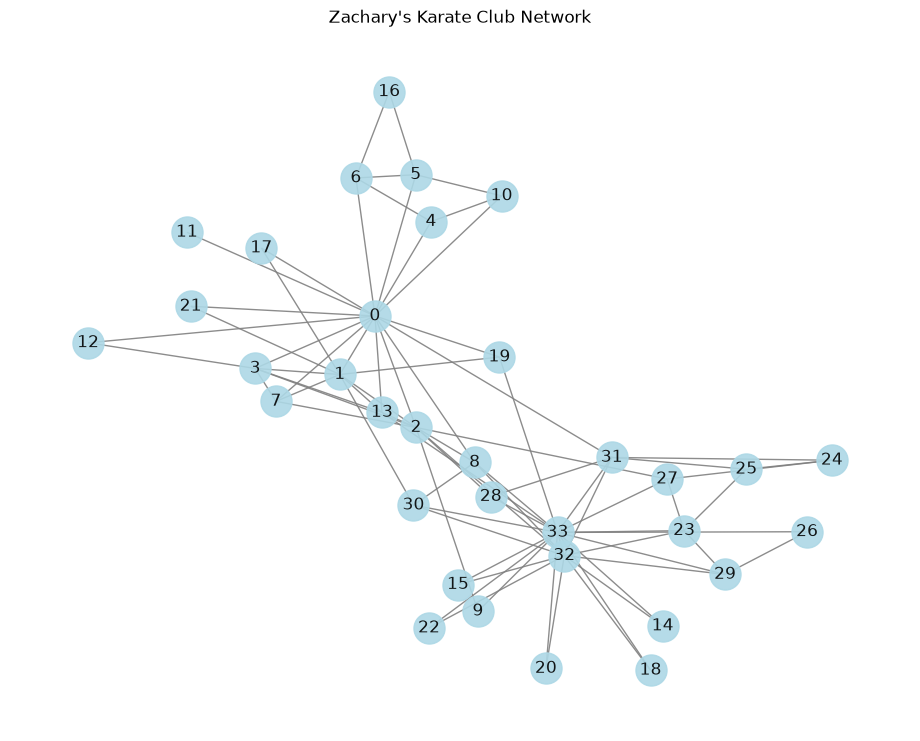

In [3]:
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(9, 7))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, alpha=0.9)
plt.title("Zachary's Karate Club Network")
plt.show()

A:
[[0 1 0 0]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]
Number of nodes: 4
Number of edges: 7

Node   Row sum / out-degree   Column sum / in-degree
0       1 / 1                 2 / 2
1       2 / 2                 2 / 2
2       2 / 2                 2 / 2
3       2 / 2                 1 / 1


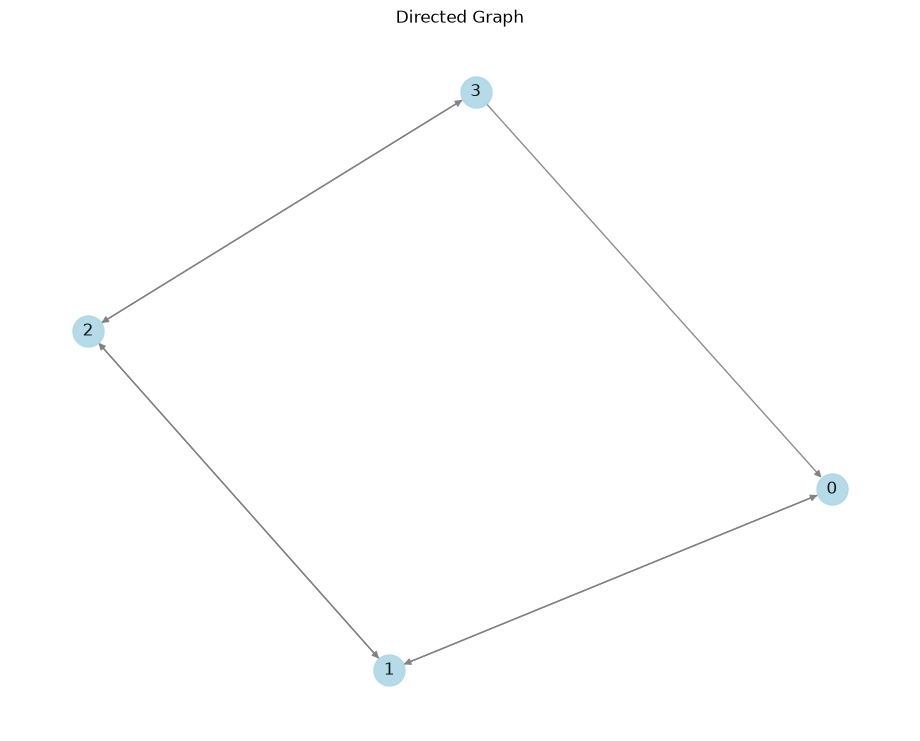


Symmetrized matrix:
[[0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]


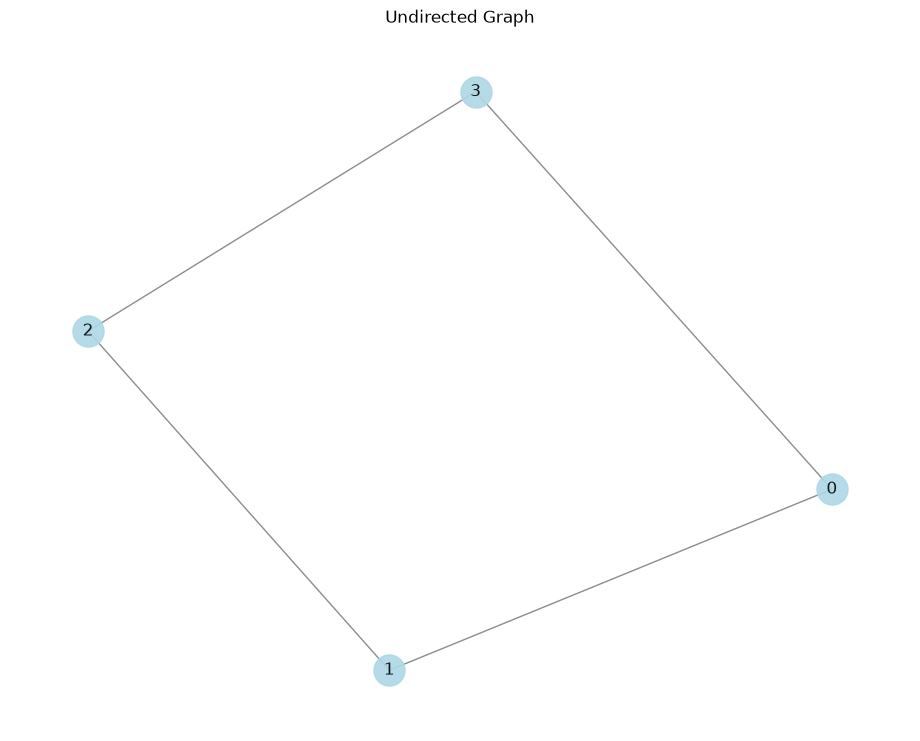


Modified matrix:
[[0 2 0 1 0]
 [1 0 1 0 0]
 [0 1 0 1 0]
 [1 0 1 1 0]
 [0 0 0 0 0]]

Edges:
[(0, 1, {'weight': 2}), (0, 3, {'weight': 1}), (1, 0, {'weight': 1}), (1, 2, {'weight': 1}), (2, 1, {'weight': 1}), (2, 3, {'weight': 1}), (3, 0, {'weight': 1}), (3, 2, {'weight': 1}), (3, 3, {'weight': 1})]


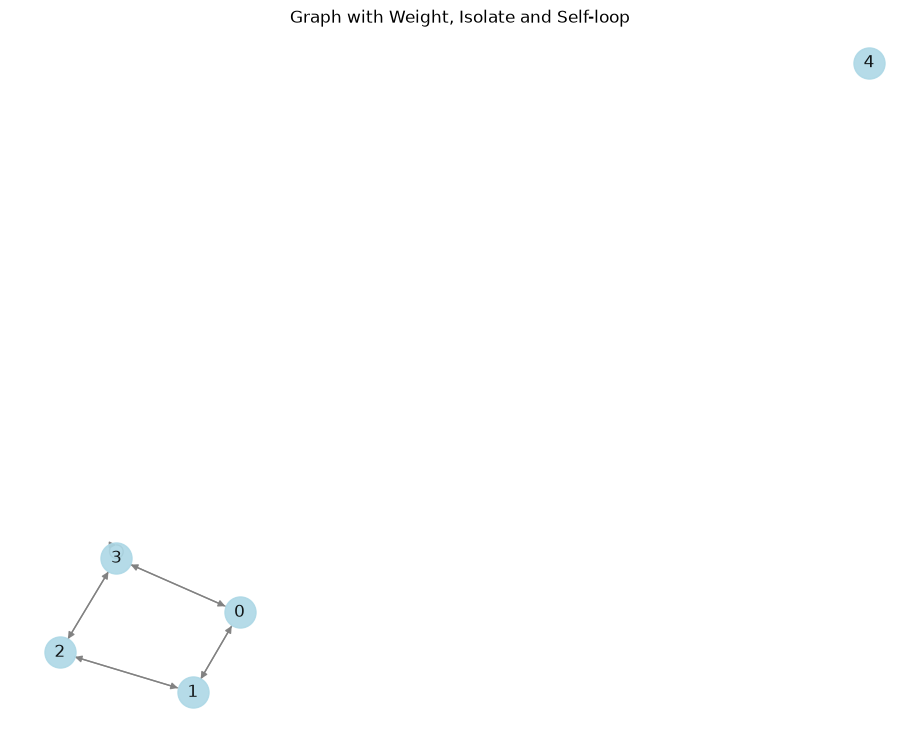

In [16]:
# Create adjacency matrix
A = np.array([
    [0, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 0, 1, 0]
])

# Create directed graph
AG = nx.from_numpy_array(A, create_using=nx.DiGraph)

print(f'A:\n{A}')
print(f'Number of nodes: {AG.number_of_nodes()}')
print(f'Number of edges: {AG.number_of_edges()}')

# Row sums and column sums
row_sums = A.sum(axis=1)
column_sums = A.sum(axis=0)

print("\nNode   Row sum / out-degree   Column sum / in-degree")
for node in AG.nodes():
    print(f"{node}       {row_sums[node]} / {AG.out_degree(node)}"
          f"                 {column_sums[node]} / {AG.in_degree(node)}")

# Draw directed graph
pos = nx.spring_layout(AG, seed=42)

plt.figure(figsize=(9, 7))
nx.draw(
    AG, pos,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray',
    node_size=500,
    alpha=0.9,
    arrows=True
)
plt.title("Directed Graph")
plt.show()


# --------------------------------------------------
# Symmetrize the matrix
# --------------------------------------------------

A_sym = np.clip(A + A.T, 0, 1)

print("\nSymmetrized matrix:")
print(A_sym)

UG = nx.from_numpy_array(A_sym)

plt.figure(figsize=(9, 7))
nx.draw(
    UG, pos,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray',
    node_size=500,
    alpha=0.9
)
plt.title("Undirected Graph")
plt.show()


# --------------------------------------------------
# Add a weight, an isolate and a self-loop
# --------------------------------------------------

A2 = np.array([
    [0, 2, 0, 1, 0],
    [1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

AG2 = nx.from_numpy_array(A2, create_using=nx.DiGraph)

print("\nModified matrix:")
print(A2)

print("\nEdges:")
print(list(AG2.edges(data=True)))

pos2 = nx.spring_layout(AG2, seed=42)

plt.figure(figsize=(9, 7))
nx.draw(
    AG2, pos2,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray',
    node_size=500,
    alpha=0.9,
    arrows=True
)
plt.title("Graph with Weight, Isolate and Self-loop")
plt.show()

# Week 1 Directed Network

Load `week1_nodes.tsv` and `week1_edges.tsv` as a directed graph. All nodes are added before any edges so the 17 isolates survive.

In [19]:
import csv
from pathlib import Path

data_dir = Path.cwd()
nodes_path = data_dir / "week1_nodes.tsv"
edges_path = data_dir / "week1_edges.tsv"

G_week1 = nx.DiGraph()

# Add every node first so isolates are retained.
with nodes_path.open(newline="", encoding="utf-8") as file:
    node_lines = (line for line in file if not line.startswith("#"))
    for row in csv.DictReader(node_lines, delimiter="\t"):
        node_id = row.pop("node_id")
        G_week1.add_node(node_id, **row)

with edges_path.open(newline="", encoding="utf-8") as file:
    edge_lines = (line for line in file if not line.startswith("#"))
    for row in csv.DictReader(edge_lines, delimiter="\t"):
        G_week1.add_edge(row["source"], row["target"])

n = G_week1.number_of_nodes()
m = G_week1.number_of_edges()
isolates = list(nx.isolates(G_week1))

print(f"n = {n}")
print(f"Directed edges = {m}")
print(f"Isolates = {len(isolates)}")

assert n == 303
assert m == 1784
assert len(isolates) == 17

KeyError: 'source'

In [ ]:
plt.figure(figsize=(12, 10))
# NetworkX's spring layout is a force-directed layout.
pos = nx.spring_layout(G_week1, seed=42, iterations=100)
nx.draw_networkx(
    G_week1,
    pos=pos,
    with_labels=False,
    node_size=20,
    node_color="steelblue",
    edge_color="gray",
    arrows=True,
    alpha=0.65,
)
plt.title("Week 1 Directed Network")
plt.axis("off")
plt.show()